# Sales Prediction using Advertising Data

This notebook analyzes how advertising spend on TV, Radio, and Newspaper affects sales. The goal is to build a simple linear regression model, evaluate its performance, and interpret the results for a business use case.

## Project objective
- Understand the relationship between advertising channels and sales
- Train a regression model to predict future sales
- Evaluate model accuracy using standard metrics
- Present business insights in a clear and professional format


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

sns.set_context('talk')

In [38]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [39]:
print("Shape:", df.shape)

df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [40]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [41]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [42]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


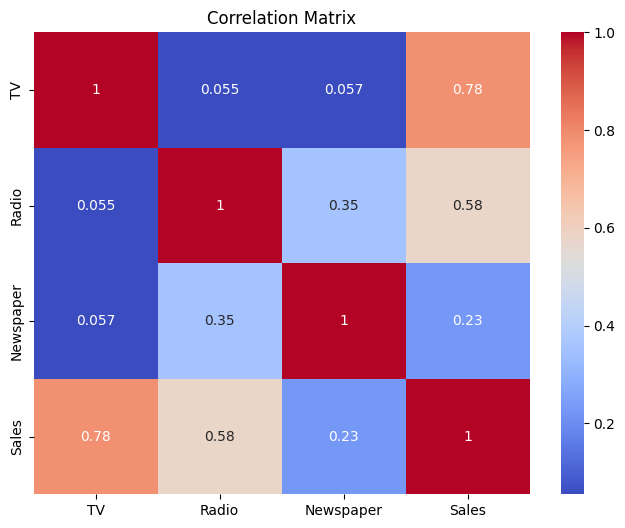

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

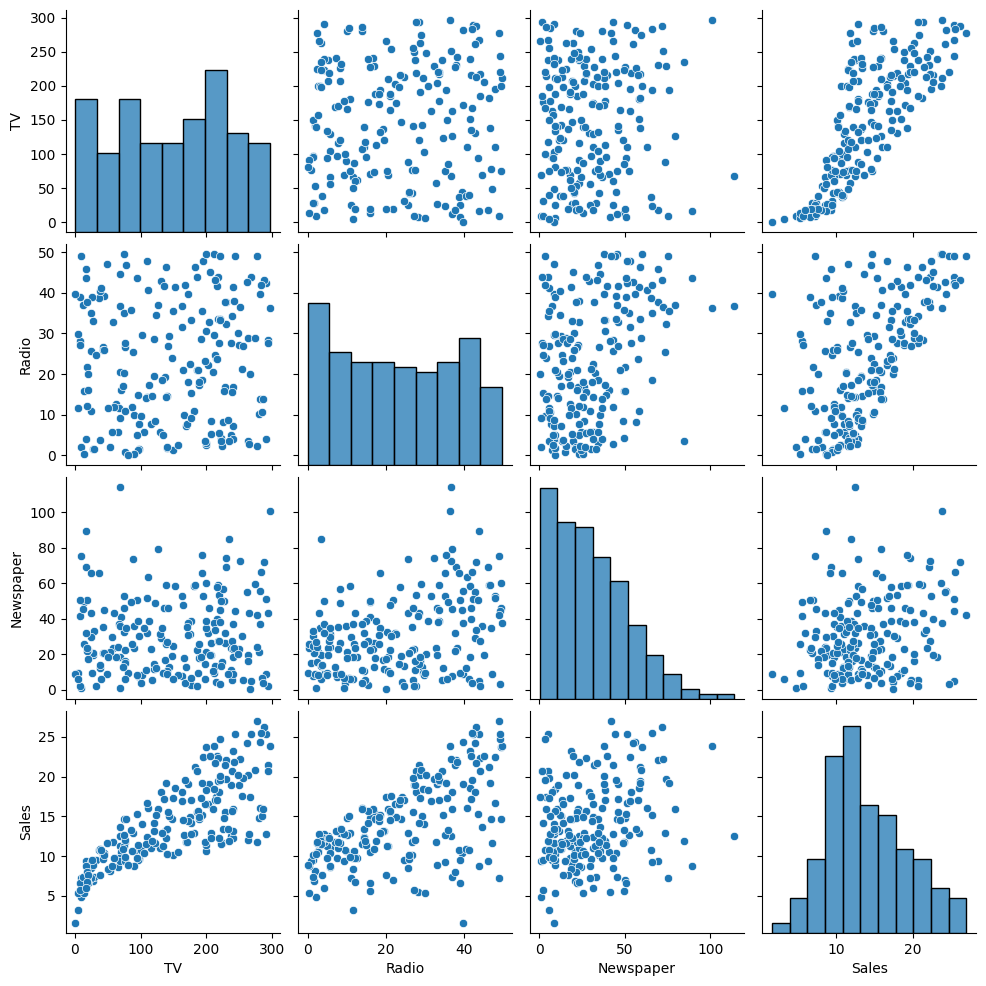

In [44]:
sns.pairplot(df)
plt.show()

In [45]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 3), (40, 3), (160,), (40,))

In [49]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [52]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

predictions.head()

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Model Performance Summary')
print(f'MAE : {mae:.3f}')
print(f'MSE : {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R² Score: {r2:.3f}')
print('\nInterpretation:')
print('A higher R² value indicates that the model explains a large portion of the variation in sales.')

Model Performance Summary
MAE : 1.461
MSE : 3.174
RMSE: 1.782
R² Score: 0.899

Interpretation:
A higher R² value indicates that the model explains a large portion of the variation in sales.


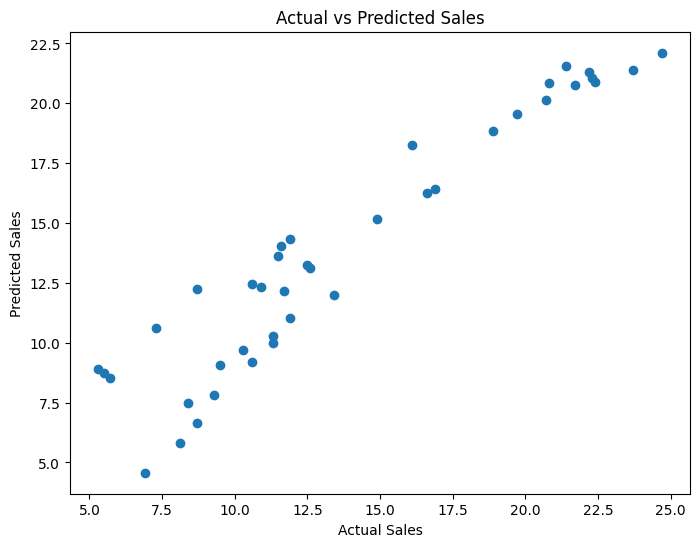

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

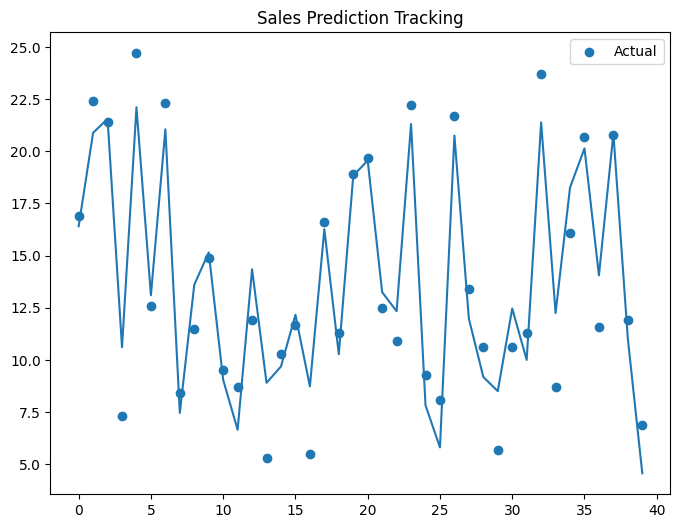

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(range(len(y_test)), y_test, label='Actual')

plt.plot(range(len(y_pred)), y_pred)

plt.legend()
plt.title("Sales Prediction Tracking")

plt.show()

In [56]:
new_data = pd.DataFrame({
    'TV':[250],
    'Radio':[40],
    'Newspaper':[20]
})

future_sales = model.predict(new_data)

print("Predicted Future Sales:", future_sales[0])

Predicted Future Sales: 21.784471161504115


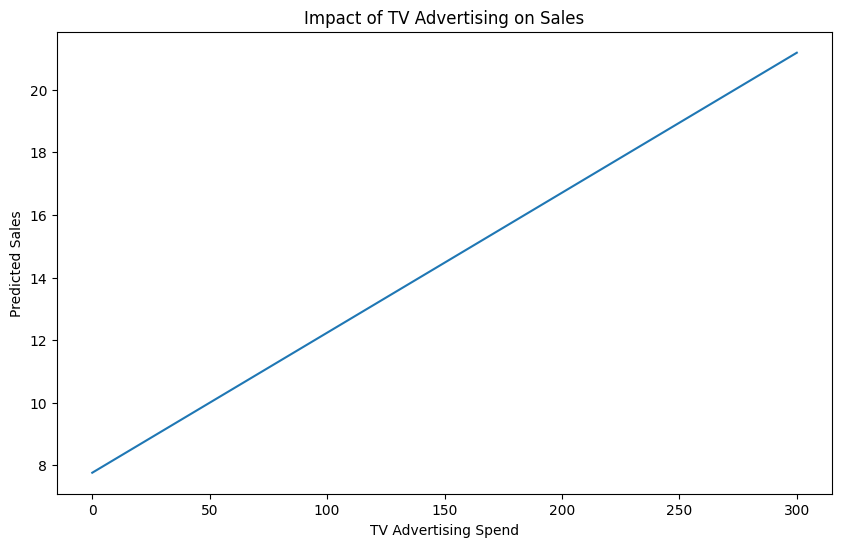

In [57]:
tv_range = np.arange(0, 301, 10)

predicted_sales = []

for tv in tv_range:
    
    sample = pd.DataFrame({
        'TV':[tv],
        'Radio':[25],
        'Newspaper':[20]
    })
    
    predicted_sales.append(model.predict(sample)[0])

plt.figure(figsize=(10,6))

plt.plot(tv_range, predicted_sales)

plt.xlabel("TV Advertising Spend")
plt.ylabel("Predicted Sales")
plt.title("Impact of TV Advertising on Sales")

plt.show()

## Business Insights and Conclusion

This model helps estimate sales based on advertising spend across TV, Radio, and Newspaper. The trained linear regression model is useful for understanding which channels have the strongest impact on sales and for planning marketing budgets more efficiently.

### Key takeaways
1. The coefficient values show which advertising channel contributes most to sales.
2. Budget allocation should prioritize channels with stronger positive influence.
3. Low-impact channels can be reduced or tested further before investing more budget.
4. The model can be used to estimate expected sales before launching a campaign.
5. Regular monitoring and retraining are recommended as marketing conditions change over time.

### Final conclusion
The notebook demonstrates a complete machine learning workflow for sales prediction using simple regression analysis. It is suitable for internship submission because it covers data preparation, model building, performance evaluation, visualization, and business interpretation.